Creación de hipotesis  con todo los pasos:

1. FORMULACION DE LA SUPOSICION
Los clientes con facturación electrónica (PaperlessBilling = Yes) presentan mayor probabilidad de churn.

2. FORMULACION DE HIPOTESIS ESTADISTICA

H0=P(Churn∣PaperlessBilling=Yes)=P(Churn∣PaperlessBilling=No)
H1=P(Churn∣PaperlessBilling=Yes)>P(Churn∣PaperlessBilling=No)

3. EXPLORACION DIRIGIDA EDA ESTRATEGICO
4. DECISION DESPUES DEL EDA
5. EXPANSION DE MULTIPLES VARIABLES
6. TRADUCCION A SELECCION DEL MODELO
7. MONTAJE EXPERIMENTAL

In [12]:
import pandas as pd
import sklearn as sk
import numpy as np
import kagglehub
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

csv = glob.glob(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))[0]
df = pd.read_csv(csv)
df.head()

100%|██████████| 172k/172k [00:00<00:00, 864kB/s]

Extracting files...
Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df["PaperlessBilling"]=np.where(df["PaperlessBilling"]=="Yes",1,0)

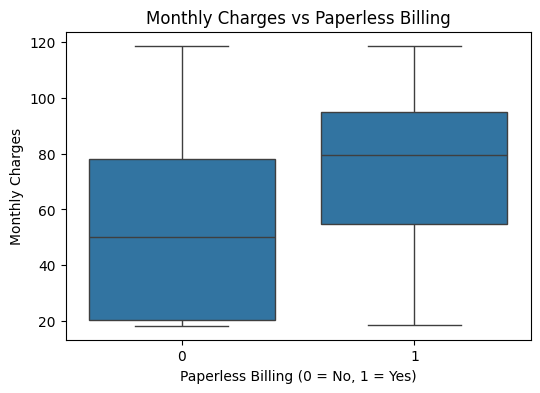

In [13]:


plt.figure(figsize=(6,4))
sns.boxplot(x="PaperlessBilling", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Paperless Billing")
plt.xlabel("Paperless Billing (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

In [14]:
# Target: Churn (Yes/No -> 1/0)
df["Churn_bin"] = np.where(df["Churn"] == "Yes", 1, 0)

# Feature: PaperlessBilling (ya lo convertiste a 0/1)
X = df[["PaperlessBilling"]].astype(float)  # matriz 2D
y = df["Churn_bin"].astype(int)

y.value_counts()

Churn_bin
0    5174
1    1869
Name: count, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # importante por posible desbalance
)

X_train.shape, X_test.shape

((5634, 1), (1409, 1))

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [17]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[469 566]
 [100 274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.45      0.58      1035
           1       0.33      0.73      0.45       374

    accuracy                           0.53      1409
   macro avg       0.58      0.59      0.52      1409
weighted avg       0.69      0.53      0.55      1409

ROC-AUC: 0.5928802087369862
